SVM · Random Forest · XGBoost

> **Instructions**  
> - Cells marked `# YOUR CODE HERE` are for you to complete.  
> - Try not to modify the pre-filled cells (data loading, preprocessing).  
> - Run cells in order from top to bottom.  
> - Fill the comparison table and answer the 3 discussion questions at the end.


##  Setup

In [1]:
# Run this cell first — installs XGBoost if not already available
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "xgboost", "-q"])


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', 'xgboost', '-q'], returncode=0)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, classification_report)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
import time

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
    print("XGBoost loaded successfully.")
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost not found — GradientBoostingClassifier will be used as fallback.")

print("All libraries loaded.")


XGBoost loaded successfully.
All libraries loaded.


## Data loading & preprocessing
This section loads `predict_income.csv`, handles categorical encoding, and prepares the train/test split.


In [3]:
# ── Load dataset ──────────────────────────────────────────────────────────────

from google.colab import files
uploaded = files.upload()          # select predict_income.csv when prompted
df = pd.read_csv(list(uploaded.keys())[0])

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Saving predict_income.csv to predict_income.csv
Shape: (48842, 15)

First 5 rows:


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:

print("Column names and dtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nTarget distribution:")
print(df['income'].value_counts())


Column names and dtypes:
age                 int64
workclass          object
fnlwgt              int64
education          object
educational-num     int64
marital-status     object
occupation         object
relationship       object
race               object
gender             object
capital-gain        int64
capital-loss        int64
hours-per-week      int64
native-country     object
income             object
dtype: object

Missing values:
age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

Target distribution:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64


In [5]:
# Encode categorical columns
df_enc = df.copy()
label_encoders = {}

categorical_cols = df_enc.select_dtypes(include=['object']).columns.tolist()
# Remove target from encoding list if it appears
if 'income' in categorical_cols:
    categorical_cols.remove('income')

for col in categorical_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))
    label_encoders[col] = le

# Encode target: '>50K' → 1, '<=50K' → 0
df_enc['income'] = df_enc['income'].str.strip().map({'>50K': 1, '<=50K': 0,
                                                      '>50K.': 1, '<=50K.': 0})

print("Encoding done. Encoded shape:", df_enc.shape)
print("Target unique values:", df_enc['income'].unique())


Encoding done. Encoded shape: (48842, 15)
Target unique values: [0 1]


In [6]:
# ── Train / test split
X = df_enc.drop(columns=['income'])
y = df_enc['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size : {X_train.shape[0]} samples")
print(f"Test size  : {X_test.shape[0]} samples")
print(f"Features   : {X_train.shape[1]}")
print(f"\nClass balance in train:\n{y_train.value_counts()}")


Train size : 39073 samples
Test size  : 9769 samples
Features   : 14

Class balance in train:
income
0    29724
1     9349
Name: count, dtype: int64


---
## Problem Statement 1 — SVM (Iris dataset)

> This problem uses the **Iris dataset** (Setosa vs Versicolor — binary classification).  
> It is independent of the income dataset above.


In [8]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load Iris — keep only Setosa (0) and Versicolor (1)
iris = load_iris()
mask = iris.target != 2
X_iris = iris.data[mask]
y_iris = iris.target[mask]

# Scale features
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(
    X_iris_scaled, y_iris, test_size=0.2, random_state=42)

print("Iris binary dataset ready.")
print(f"Train: {X_tr_i.shape[0]}  |  Test: {X_te_i.shape[0]}")


Iris binary dataset ready.
Train: 80  |  Test: 20


### 1a. Train SVM with linear kernel

In [9]:
# YOUR CODE HERE
# Train an SVM with a linear kernel
# Evaluate using accuracy, precision, recall, F1-score
# Try at least two values of C (e.g., C=0.1 and C=10)

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train SVM with C = 0.1
svm_c1 = SVC(kernel='linear', C=0.1)
svm_c1.fit(X_tr_i, y_tr_i)
y_pred_c1 = svm_c1.predict(X_te_i)

# Train SVM with C = 10
svm_c2 = SVC(kernel='linear', C=10)
svm_c2.fit(X_tr_i, y_tr_i)
y_pred_c2 = svm_c2.predict(X_te_i)

# Evaluation function
def evaluate(y_true, y_pred):
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("-" * 30)

# Results
print("SVM with C = 0.1")
evaluate(y_te_i, y_pred_c1)

print("SVM with C = 10")
evaluate(y_te_i, y_pred_c2)

SVM with C = 0.1
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
------------------------------
SVM with C = 10
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
------------------------------


### 1b. Train SVM with RBF kernel

In [10]:
# YOUR CODE HERE
# Train an SVM with RBF kernel
# Try at least two combinations of C and gamma (e.g., C=1 gamma=0.1 and C=10 gamma=1)
# Print classification_report for each
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# SVM with RBF kernel: C=1, gamma=0.1
svm_rbf_1 = SVC(kernel='rbf', C=1, gamma=0.1)
svm_rbf_1.fit(X_tr_i, y_tr_i)
y_pred_rbf_1 = svm_rbf_1.predict(X_te_i)

print("RBF SVM (C=1, gamma=0.1)")
print(classification_report(y_te_i, y_pred_rbf_1))
print("-" * 40)

# SVM with RBF kernel: C=10, gamma=1
svm_rbf_2 = SVC(kernel='rbf', C=10, gamma=1)
svm_rbf_2.fit(X_tr_i, y_tr_i)
y_pred_rbf_2 = svm_rbf_2.predict(X_te_i)

print("RBF SVM (C=10, gamma=1)")
print(classification_report(y_te_i, y_pred_rbf_2))



RBF SVM (C=1, gamma=0.1)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

----------------------------------------
RBF SVM (C=10, gamma=1)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



### 1c. Compare kernels and comment

In [11]:
# YOUR CODE HERE
# Print a summary table comparing linear vs RBF results
# (you can use a simple dict → pd.DataFrame)
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Create summary dictionary
results = {
    "Model": ["Linear (C=0.1)", "Linear (C=10)", "RBF (C=1, γ=0.1)", "RBF (C=10, γ=1)"],
    "Accuracy": [
        accuracy_score(y_te_i, y_pred_c1),
        accuracy_score(y_te_i, y_pred_c2),
        accuracy_score(y_te_i, y_pred_rbf_1),
        accuracy_score(y_te_i, y_pred_rbf_2)
    ],
    "Precision": [
        precision_score(y_te_i, y_pred_c1),
        precision_score(y_te_i, y_pred_c2),
        precision_score(y_te_i, y_pred_rbf_1),
        precision_score(y_te_i, y_pred_rbf_2)
    ],
    "Recall": [
        recall_score(y_te_i, y_pred_c1),
        recall_score(y_te_i, y_pred_c2),
        recall_score(y_te_i, y_pred_rbf_1),
        recall_score(y_te_i, y_pred_rbf_2)
    ],
    "F1 Score": [
        f1_score(y_te_i, y_pred_c1),
        f1_score(y_te_i, y_pred_c2),
        f1_score(y_te_i, y_pred_rbf_1),
        f1_score(y_te_i, y_pred_rbf_2)
    ]
}

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Display table
print(results_df)


              Model  Accuracy  Precision  Recall  F1 Score
0    Linear (C=0.1)       1.0        1.0     1.0       1.0
1     Linear (C=10)       1.0        1.0     1.0       1.0
2  RBF (C=1, γ=0.1)       1.0        1.0     1.0       1.0
3   RBF (C=10, γ=1)       1.0        1.0     1.0       1.0


---
## Problem Statement 2 — Random Forest
> Use `X_train, X_test, y_train, y_test` from the income dataset (already prepared above).


### 2a. Train Random Forest and evaluate

Accuracy: 0.8612959361244754


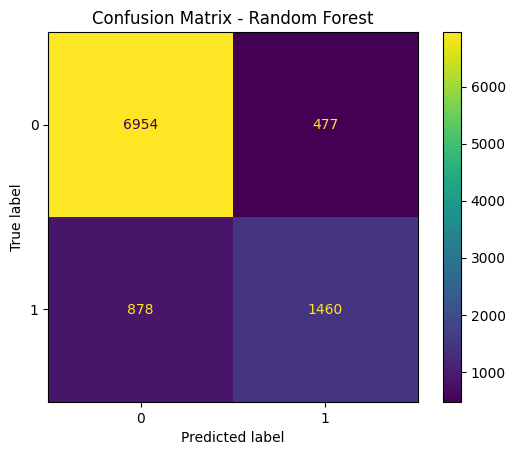

In [24]:
# YOUR CODE HERE
# Train a RandomForestClassifier (use random_state=42)
# Print accuracy and plot the confusion matrix using ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - Random Forest")
plt.show()


### 2b. Feature importance plot

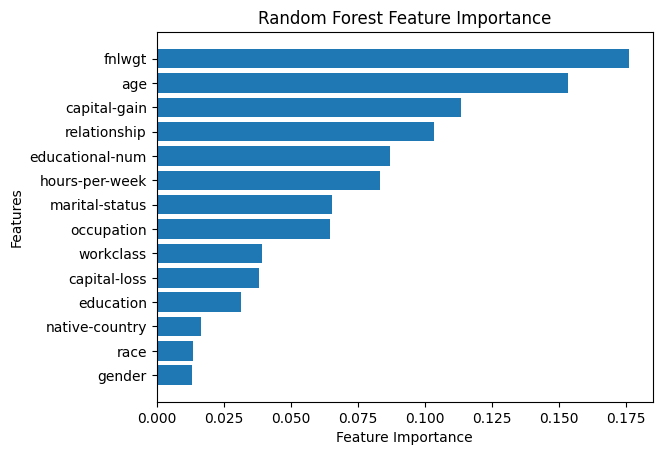

In [13]:
#  YOUR CODE HERE
# Plot a horizontal bar chart of feature importances
# Sort by importance (highest at top)
# Label axes clearly
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
importances = rf.feature_importances_

# Convert to DataFrame
feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
})

# Sort by importance (highest first)
feat_imp = feat_imp.sort_values(by="Importance", ascending=True)

# Plot horizontal bar chart
plt.figure()
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.show()


### 2c. Effect of n_estimators

In [14]:
#  YOUR CODE HERE
# Train two Random Forest models:
#   - n_estimators = 50
#   - n_estimators = 200
# Record accuracy and training time for each
# Print a comparison


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time
import pandas as pd

results = []

for n in [50, 200]:
    start = time.time()

    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)

    end = time.time()

    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    results.append({
        "n_estimators": n,
        "Accuracy": acc,
        "Training Time (sec)": end - start
    })

# Convert to DataFrame and print
results_df = pd.DataFrame(results)
print(results_df)

   n_estimators  Accuracy  Training Time (sec)
0            50  0.860784             6.147485
1           200  0.860272            12.204729


---
## Problem Statement 3 — XGBoost
> Use the same income dataset split. Compare directly with Random Forest.


### 3a. Train XGBoost and evaluate

In [15]:
# YOUR CODE HERE
# If XGB_AVAILABLE is True  → use XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
# If XGB_AVAILABLE is False → use GradientBoostingClassifier(random_state=42)
# Evaluate using accuracy, precision, recall, F1-score
# Record training time using time.time()
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Choose model based on availability
if XGB_AVAILABLE:
    from xgboost import XGBClassifier
    model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    model_name = "XGBoost"
else:
    from sklearn.ensemble import GradientBoostingClassifier
    model = GradientBoostingClassifier(random_state=42)
    model_name = "Gradient Boosting"

# Train and record time
start = time.time()
model.fit(X_train, y_train)
end = time.time()

# Predictions
y_pred = model.predict(X_test)

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print results
print(f"Model: {model_name}")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)
print("Training Time (sec):", end - start)



Model: XGBoost
Accuracy : 0.8726584092537619
Precision: 0.7768218623481782
Recall   : 0.6565440547476475
F1 Score : 0.7116365322206769
Training Time (sec): 2.2739017009735107


### 3b. Overfitting check — train vs test score

In [20]:
# YOUR CODE HERE
# Print both train accuracy and test accuracy for:
#   - Your Random Forest model (from PS2a)
#   - Your XGBoost model (from PS3a)
# A large gap between train and test = overfitting
from sklearn.metrics import accuracy_score

# --- Random Forest (already trained) ---
rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)

print("Random Forest:")
print("Train Accuracy:", accuracy_score(y_train, rf_train_pred))
print("Test Accuracy :", accuracy_score(y_test, rf_test_pred))
print("-" * 40)

# --- XGBoost / Gradient Boosting (assumes model already trained) ---
xgb_train_pred = model.predict(X_train)
xgb_test_pred = model.predict(X_test)

print("XGBoost / Gradient Boosting:")
print("Train Accuracy:", accuracy_score(y_train, xgb_train_pred))
print("Test Accuracy :", accuracy_score(y_test, xgb_test_pred))



Random Forest:
Train Accuracy: 0.9999232206382924
Test Accuracy : 0.8612959361244754
----------------------------------------
XGBoost / Gradient Boosting:
Train Accuracy: 0.899777339851048
Test Accuracy : 0.8726584092537619


---
## GridSearchCV — hyperparameter tuning
> Apply GridSearchCV to **one** model of your choice: SVM, Random Forest, or XGBoost.  
> Keep the param grid small (2–3 values per parameter) to avoid long runtimes.


In [21]:
# YOUR CODE HERE
# Example param grid for Random Forest (modify as needed):
# param_grid = {
#     'n_estimators': [50, 100],
#     'max_depth': [None, 10],
#     'min_samples_split': [2, 5]
# }
# Use cv=5, scoring='accuracy'
# Print best_params_ and best_score_
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Parameter grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}

# Model
rf = RandomForestClassifier(random_state=42)

# Grid Search
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit
grid.fit(X_train, y_train)

# Results
print("Best Parameters:", grid.best_params_)
print("Best CV Score :", grid.best_score_)


Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Score : 0.8594423186167323


---
## ROC Curve — best performing classifier
> Plot the ROC curve for the model that achieved the highest test accuracy.


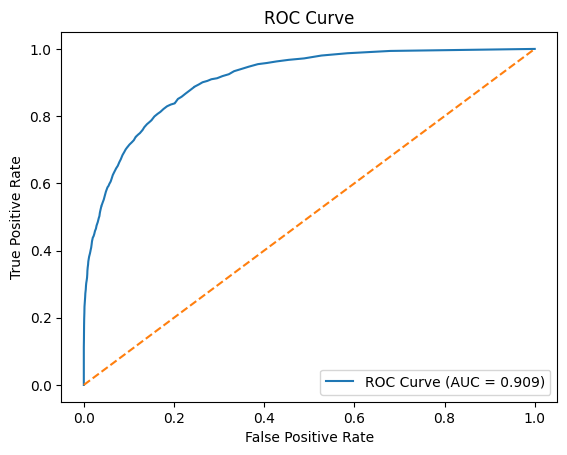

In [25]:
# YOUR CODE HERE
# Use predict_proba() or decision_function() to get scores
# Compute fpr, tpr, thresholds using roc_curve()
# Compute AUC using auc()
# Plot the curve with AUC value in the legend
# Add a dashed diagonal line (random classifier baseline)
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Choose your trained model (rf or model)
clf = rf

# Get scores
if hasattr(clf, "predict_proba"):
    y_scores = clf.predict_proba(X_test)[:, 1]
else:
    y_scores = clf.decision_function(X_test)

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# AUC
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


---
## Comparison table
Fill in your actual results below.


In [26]:
#  Fill in your results and run this cell to display the table
# Compare Accuracy, Precision, Recall & F1-score for Model SVM (Linear), SVM (RBF), Random Forest, XGBoost

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Create results table
results = pd.DataFrame({
    "Model": ["SVM (Linear)", "SVM (RBF)", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_te_i, y_pred_c2),        # Linear SVM (C=10)
        accuracy_score(y_te_i, y_pred_rbf_2),     # RBF SVM (C=10, gamma=1)
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, model.predict(X_test))
    ],
    "Precision": [
        precision_score(y_te_i, y_pred_c2),
        precision_score(y_te_i, y_pred_rbf_2),
        precision_score(y_test, rf.predict(X_test)),
        precision_score(y_test, model.predict(X_test))
    ],
    "Recall": [
        recall_score(y_te_i, y_pred_c2),
        recall_score(y_te_i, y_pred_rbf_2),
        recall_score(y_test, rf.predict(X_test)),
        recall_score(y_test, model.predict(X_test))
    ],
    "F1 Score": [
        f1_score(y_te_i, y_pred_c2),
        f1_score(y_te_i, y_pred_rbf_2),
        f1_score(y_test, rf.predict(X_test)),
        f1_score(y_test, model.predict(X_test))
    ]
})

print(results)

           Model  Accuracy  Precision    Recall  F1 Score
0   SVM (Linear)  1.000000   1.000000  1.000000  1.000000
1      SVM (RBF)  1.000000   1.000000  1.000000  1.000000
2  Random Forest  0.861296   0.753743  0.624465  0.683041
3        XGBoost  0.872658   0.776822  0.656544  0.711637
